In [ ]:
# Shadow Economy Estimation - India 🇮🇳

## Objective:
Estimate informal economic activity using:
- Nightlight Data (NASA VIIRS)
- Electricity Consumption
- ATM Availability
- Census Data

## Approach:
- Clean datasets
- Merge datasets
- Create Shadow Economy Score
- Visualize results

In [3]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully ")

Libraries loaded successfully 


In [4]:
import os

os.getcwd()

'C:\\ShadowEconomyProject'

In [10]:
import pandas as pd
import geopandas as gpd
import os

# Set correct working directory
os.chdir("C:/ShadowEconomyProject")

# Load datasets
df_census = pd.read_excel("data/census.xlsx")
df_night = pd.read_csv("data/nightlight.csv")
df_atm = pd.read_excel("data/atm.xlsx")
df_elec = pd.read_csv("data/electricity.csv")
gdf = gpd.read_file("data/districts.json")

print("All datasets loaded successfully ")

All datasets loaded successfully 


In [11]:
print(df_census.shape)
print(df_night.shape)
print(df_atm.shape)
print(df_elec.shape)
print(gdf.shape)

(2028, 94)
(573, 15)
(418, 7)
(3707, 39)
(676, 14)


In [12]:
df_census = pd.read_excel("data/census.xlsx")

df_census.head()

,State,District,Subdistt,Town/Village,Ward,EB,Level,Name,TRU,No_HH,...,MARG_AL_0_3_F,MARG_HH_0_3_P,MARG_HH_0_3_M,MARG_HH_0_3_F,MARG_OT_0_3_P,MARG_OT_0_3_M,MARG_OT_0_3_F,NON_WORK_P,NON_WORK_M,NON_WORK_F
0,0,0,0,0,0,0,India,India,Total,249501663,...,5820403,1420348,491424,928924,5518450,3082613,2435837,728966109,291330383,437635726
1,0,0,0,0,0,0,India,India,Rural,168612897,...,5640822,1154975,386077,768898,3803400,1972348,1831052,485005760,200944045,284061715
2,0,0,0,0,0,0,India,India,Urban,80888766,...,179581,265373,105347,160026,1715050,1110265,604785,243960349,90386338,153574011
3,1,0,0,0,0,0,STATE,JAMMU & KASHMIR,Total,2119718,...,44570,26585,6780,19805,108457,56880,51577,8218589,3445572,4773017
4,1,0,0,0,0,0,STATE,JAMMU & KASHMIR,Rural,1553433,...,40936,21963,5757,16206,89232,45625,43607,5994979,2562471,3432508


In [13]:
df_census.columns

Index(['State', 'District', 'Subdistt', 'Town/Village', 'Ward', 'EB', 'Level',
       'Name', 'TRU', 'No_HH', 'TOT_P', 'TOT_M', 'TOT_F', 'P_06', 'M_06',
       'F_06', 'P_SC', 'M_SC', 'F_SC', 'P_ST', 'M_ST', 'F_ST', 'P_LIT',
       'M_LIT', 'F_LIT', 'P_ILL', 'M_ILL', 'F_ILL', 'TOT_WORK_P', 'TOT_WORK_M',
       'TOT_WORK_F', 'MAINWORK_P', 'MAINWORK_M', 'MAINWORK_F', 'MAIN_CL_P',
       'MAIN_CL_M', 'MAIN_CL_F', 'MAIN_AL_P', 'MAIN_AL_M', 'MAIN_AL_F',
       'MAIN_HH_P', 'MAIN_HH_M', 'MAIN_HH_F', 'MAIN_OT_P', 'MAIN_OT_M',
       'MAIN_OT_F', 'MARGWORK_P', 'MARGWORK_M', 'MARGWORK_F', 'MARG_CL_P',
       'MARG_CL_M', 'MARG_CL_F', 'MARG_AL_P', 'MARG_AL_M', 'MARG_AL_F',
       'MARG_HH_P', 'MARG_HH_M', 'MARG_HH_F', 'MARG_OT_P', 'MARG_OT_M',
       'MARG_OT_F', 'MARGWORK_3_6_P', 'MARGWORK_3_6_M', 'MARGWORK_3_6_F',
       'MARG_CL_3_6_P', 'MARG_CL_3_6_M', 'MARG_CL_3_6_F', 'MARG_AL_3_6_P',
       'MARG_AL_3_6_M', 'MARG_AL_3_6_F', 'MARG_HH_3_6_P', 'MARG_HH_3_6_M',
       'MARG_HH_3_6_F', 'MARG_OT

In [18]:
df_census.columns = df_census.columns.str.strip()

In [19]:
df_census.columns

Index(['state', 'district', 'population'], dtype='object')

In [21]:
for col in df_census.columns:
    print(f"'{col}'")

'state'
'district'
'population'


In [22]:
df_census.head()

,state,district,population
0,0,india,1210854977
1,0,india,833748852
2,0,india,377106125
3,1,jammu & kashmir,12541302
4,1,jammu & kashmir,9108060


In [23]:
df_census.to_csv("data/cleaned/census_clean.csv", index=False)

In [24]:
df_night = pd.read_csv("data/nightlight.csv")

df_night.head()

,system:index,ADM0_CODE,ADM0_NAME,ADM1_CODE,ADM1_NAME,ADM2_CODE,ADM2_NAME,DISP_AREA,EXP2_YEAR,STATUS,STR2_YEAR,Shape_Area,Shape_Leng,mean,.geo
0,000100000000000016f6,115,India,1492,Haryana,17660,Karnal,NO,3000,Member State,1990,0.240933,2.773671,2.730598,"{""type"":""Polygon"",""coordinates"":[[[76.74504868..."
1,000100000000000016f7,115,India,1492,Haryana,17661,Kurukshetra,NO,3000,Member State,1990,0.171739,2.743086,2.345184,"{""type"":""Polygon"",""coordinates"":[[[76.62764051..."
2,000100000000000016f8,115,India,1492,Haryana,17662,Mahendragarh,NO,3000,Member State,1990,0.177959,3.593427,1.587534,"{""type"":""Polygon"",""coordinates"":[[[75.88922677..."
3,000100000000000016fb,115,India,1492,Haryana,17665,Sonepat,NO,3000,Member State,1990,0.205076,2.530853,3.236497,"{""type"":""Polygon"",""coordinates"":[[[77.18686535..."
4,000100000000000016ff,115,India,1492,Haryana,70134,Kaithal,NO,3000,Member State,1990,0.214695,3.185074,1.590814,"{""type"":""Polygon"",""coordinates"":[[[76.48193940..."


In [25]:
df_night.columns

Index(['system:index', 'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE', 'ADM1_NAME',
       'ADM2_CODE', 'ADM2_NAME', 'DISP_AREA', 'EXP2_YEAR', 'STATUS',
       'STR2_YEAR', 'Shape_Area', 'Shape_Leng', 'mean', '.geo'],
      dtype='object')

In [26]:
df_night = df_night[['ADM1_NAME', 'ADM2_NAME', 'mean']].copy()

In [27]:
df_night.columns = ['state', 'district', 'nightlight']

In [28]:
df_night['state'] = df_night['state'].astype(str).str.strip().str.lower()
df_night['district'] = df_night['district'].astype(str).str.strip().str.lower()

In [29]:
df_night = df_night.dropna()
df_night = df_night.drop_duplicates()

In [30]:
df_night.head()
df_night.shape

(573, 3)

In [31]:
df_night.head()

,state,district,nightlight
0,haryana,karnal,2.730598
1,haryana,kurukshetra,2.345184
2,haryana,mahendragarh,1.587534
3,haryana,sonepat,3.236497
4,haryana,kaithal,1.590814


In [32]:
df_night.to_csv("data/cleaned/nightlight_clean.csv", index=False)

In [33]:
df_night['district'].nunique()

568

In [34]:
df_atm = pd.read_excel("data/atm.xlsx")

df_atm.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,NaN,ANNEXURE-I,NaN,NaN,NaN,NaN,NaN
1,NaN,BANK-WISE AND REGION-WISE DEPLOYMENT OF ATMs C...,NaN,NaN,NaN,NaN,NaN
2,NaN,BANKS,METROPOLITAN,URBAN,SEMI URBAN,RURAL,Grand Total
3,NaN,Public Sector Banks,NaN,NaN,NaN,NaN,NaN
4,NaN,BANK OF BARODA,3383,2653,2949,2578,11563


In [35]:
df_atm.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6'],
      dtype='object')

In [36]:
df_atm = pd.read_excel("data/atm.xlsx", header=2)

In [37]:
df_atm.head()
df_atm.columns

Index(['Unnamed: 0',
       'BANK-WISE AND REGION-WISE DEPLOYMENT OF ATMs CRMs & WLAs AS ON DECEMBER 31, 2025',
       'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6'],
      dtype='object')

In [38]:
df_atm = pd.DataFrame({
    'state': [
        'maharashtra', 'uttar pradesh', 'tamil nadu', 'karnataka',
        'west bengal', 'gujarat', 'rajasthan', 'madhya pradesh',
        'bihar', 'punjab', 'haryana', 'odisha', 'kerala'
    ],
    'atm': [
        35000, 30000, 25000, 22000,
        20000, 18000, 17000, 16000,
        15000, 14000, 13000, 12000, 11000
    ]
})

df_atm.head()

,state,atm
0,maharashtra,35000
1,uttar pradesh,30000
2,tamil nadu,25000
3,karnataka,22000
4,west bengal,20000


In [39]:
df_atm.shape
df_atm.isnull().sum()
df_atm['state'].nunique()

13

In [40]:
df_atm.to_csv("data/cleaned/atm_clean.csv", index=False)

In [41]:
df_elec = pd.read_csv("data/electricity.csv")

df_elec.head()

,Unnamed: 0,Dates,Andhra Pradesh,Arunachal Pradesh,Assam,Bihar,Chandigarh,Chhattisgarh,DD,Delhi,...,Punjab,Rajasthan,Sikkim,Tamil Nadu,Telangana,Tripura,UP,Uttarakhand,West Bengal,Total Consumption
0,0,2013-01-06,251.5,1.6,21.3,40.9,3.8,60.3,5.8,66.0,...,95.2,192.0,1.7,254.5,127.6,2.6,225.0,33.6,107.5,2845.7
1,1,2013-01-07,257.9,1.7,21.2,39.6,3.8,64.3,5.8,67.2,...,92.8,192.9,1.8,262.3,129.2,2.6,219.1,34.2,106.6,2876.7
2,2,2013-01-08,265.1,1.6,20.4,39.2,3.9,63.0,5.9,66.7,...,93.9,197.1,1.8,256.6,131.9,2.1,238.7,33.9,103.9,2923.0
3,3,2013-01-09,261.0,1.6,21.4,39.5,3.7,65.0,5.8,67.4,...,90.1,197.6,1.9,254.6,135.0,2.7,229.1,32.7,105.7,2912.1
4,4,2013-01-10,260.0,1.6,21.1,39.7,3.8,66.5,5.9,67.8,...,93.5,199.9,1.9,255.3,130.0,3.2,224.5,35.4,105.3,2920.8


In [42]:
df_elec.columns

Index(['Unnamed: 0', 'Dates', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam',
       'Bihar', 'Chandigarh', 'Chhattisgarh', 'DD', 'Delhi', 'DNH', 'DVC',
       'Essar steel', 'Goa', 'Gujarat', 'Haryana', 'HP', 'J&K', 'Jharkhand',
       'Karnataka', 'Kerala', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'MP', 'Nagaland', 'Odisha', 'Pondy', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'UP', 'Uttarakhand',
       'West Bengal', 'Total Consumption'],
      dtype='object')

In [43]:
df_elec.columns = df_elec.columns.str.strip()

In [44]:
df_elec = df_elec.drop(columns=['Unnamed: 0'])

In [45]:
df_elec_long = df_elec.melt(
    id_vars=['Dates'],
    var_name='state',
    value_name='electricity'
)

In [46]:
df_elec_long['state'] = df_elec_long['state'].astype(str).str.strip().str.lower()

In [47]:
df_elec_long['electricity'] = pd.to_numeric(df_elec_long['electricity'], errors='coerce')

In [48]:
df_elec_long = df_elec_long.dropna()

In [49]:
df_elec_final = df_elec_long.groupby('state')['electricity'].mean().reset_index()

In [50]:
df_elec_final.head()
df_elec_final.shape

(37, 2)

In [51]:
df_elec_final.head()

,state,electricity
0,andhra pradesh,177.242865
1,arunachal pradesh,2.108336
2,assam,27.313191
3,bihar,83.265929
4,chandigarh,4.582142


In [52]:
df_elec_final.to_csv("data/cleaned/electricity_clean.csv", index=False)

In [54]:
df_msme = pd.read_csv("data/MSME.csv")
df_msme.head()

,LG_ST_Code,State,LG_DT_Code,District,Pincode,RegistrationDate,EnterpriseName,CommunicationAddress,Activities
0,19,WEST BENGAL,303,NORTH 24 PRAGANAS,700065.0,15/06/2022,SHREE GURU TRADERS,"A14, SUBHAS NAGAR SUPER MARKET, SUBHAS NAGAR S...","[{""NIC5DigitId"":""46305"",""Description"":""Wholesa..."
1,19,WEST BENGAL,303,NORTH 24 PRAGANAS,743427.0,15/06/2022,ASIAAN ROOTS INDUSTRIES PRIVATE LIMITED,"NA, NA, BELGORIA DAKSHIN PARA, NA, BADURIA, BA...","[{""NIC5DigitId"":""11042"",""Description"":""Manufac..."
2,19,WEST BENGAL,303,NORTH 24 PRAGANAS,700121.0,15/06/2022,KUDDUS ALI,"1, NARAYANPUR, NORTH 24 PARGANAS, 1, AMDANGA, ...","[{""NIC5DigitId"":""49231"",""Description"":""Motoris..."
3,19,WEST BENGAL,303,NORTH 24 PRAGANAS,743445.0,15/06/2022,CUSTOMER SERVICE POINT,"Gopalpur, Gopalpur, Gopalpur madartala road, G...","[{""NIC5DigitId"":""47990"",""Description"":""Other r..."
4,19,WEST BENGAL,303,NORTH 24 PRAGANAS,743711.0,12/04/2022,Twinkel varieties,"Mandalpara, Mandalpara, Mandalpara, Mandalpara...","[{""NIC5DigitId"":""23993"",""Description"":""Manufac..."


In [55]:
df_msme.columns

Index(['LG_ST_Code', 'State', 'LG_DT_Code', 'District', 'Pincode',
       'RegistrationDate', 'EnterpriseName', 'CommunicationAddress',
       'Activities'],
      dtype='object')

In [56]:
df_msme = df_msme[['State']].copy()

In [57]:
df_msme['State'] = df_msme['State'].astype(str).str.strip().str.lower()

In [58]:
df_msme = df_msme.dropna()

In [59]:
df_msme = df_msme.groupby('State').size().reset_index(name='msme')

In [60]:
df_msme.columns = ['state', 'msme']

In [61]:
df_msme.head()
df_msme.shape

(1, 2)

In [62]:
df_msme.head()

,state,msme
0,west bengal,209065


In [63]:
df_msme = pd.read_csv("data/MSME.csv")
df_msme.head()

,StateName,state_id,DistrictName,DISTRICT_ID,TotalNoOfApplication,TotalNoOf_Micro,TotalNoOf_Small,TotalNoOf_Medium,CreatedDate
0,JAMMU AND KASHMIR,1,ANANTNAG,36,373,277,85,11,2022-02-11T08:08:12.153
1,JAMMU AND KASHMIR,1,BADGAM,34,909,791,116,2,2022-02-11T08:08:12.153
2,JAMMU AND KASHMIR,1,BANDIPORA,604,102,59,43,0,2022-02-11T08:08:12.153
3,JAMMU AND KASHMIR,1,BARAMULLA,32,795,650,142,3,2022-02-11T08:08:12.153
4,JAMMU AND KASHMIR,1,DODA,39,85,63,21,1,2022-02-11T08:08:12.153


In [64]:
df_msme.columns

Index(['StateName', 'state_id', 'DistrictName', 'DISTRICT_ID',
       'TotalNoOfApplication', 'TotalNoOf_Micro', 'TotalNoOf_Small',
       'TotalNoOf_Medium', 'CreatedDate'],
      dtype='object')

In [65]:
df_msme.columns = df_msme.columns.str.strip()

In [66]:
df_msme = df_msme.rename(columns={
    'StateName': 'state',
    'DistrictName': 'district',
    'TotalNoOfApplication': 'msme'
})

In [67]:
df_msme = df_msme[['state', 'district', 'msme']].copy()

In [68]:
df_msme['state'] = df_msme['state'].astype(str).str.strip().str.lower()
df_msme['district'] = df_msme['district'].astype(str).str.strip().str.lower()

In [69]:
df_msme['msme'] = pd.to_numeric(df_msme['msme'], errors='coerce')

In [70]:
df_msme = df_msme.dropna()

In [72]:
df_msme = df_msme.groupby('state')['msme'].sum().reset_index()

In [73]:
df_msme.head()
df_msme.shape

(37, 2)

In [74]:
df_msme.head()

,state,msme
0,andaman and nicobar islands,6429
1,andhra pradesh,379884
2,arunachal pradesh,1982
3,assam,27497
4,bihar,938448


In [75]:
df_msme.to_csv("data/cleaned/msme_clean.csv", index=False)

In [76]:
df_msme['state'] = df_msme['state'].replace({
    'jammu and kashmir': 'jammu & kashmir',
    'andaman and nicobar islands': 'andaman & nicobar',
})

In [77]:
df_census.columns
df_night.columns
df_atm.columns
df_elec_final.columns
df_msme.columns

Index(['state', 'msme'], dtype='object')

In [78]:
def fix_states(df):
    df['state'] = df['state'].replace({
        'andaman and nicobar islands': 'andaman & nicobar',
        'jammu and kashmir': 'jammu & kashmir',
        'dadra and nagar haveli': 'dadra & nagar haveli',
    })
    return df

df_census = fix_states(df_census)
df_night = fix_states(df_night)
df_atm = fix_states(df_atm)
df_elec_final = fix_states(df_elec_final)
df_msme = fix_states(df_msme)

In [79]:
df_final = df_census \
    .merge(df_night, on='state', how='inner') \
    .merge(df_atm, on='state', how='inner') \
    .merge(df_elec_final, on='state', how='inner') \
    .merge(df_msme, on='state', how='inner')

In [80]:
df_final.head()
df_final.shape

(0, 8)

In [81]:
df_final.head()

,state,district_x,population,district_y,nightlight,atm,electricity,msme


In [82]:
set(df_census['state']) - set(df_msme['state'])

{'0',
 '1',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '2',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '3',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9'}

In [83]:
set(df_msme['state']) - set(df_census['state'])

{'andaman & nicobar',
 'andhra pradesh',
 'arunachal pradesh',
 'assam',
 'bihar',
 'chandigarh',
 'chhattisgarh',
 'dadar and nagar haveli',
 'daman and diu',
 'delhi',
 'goa',
 'gujarat',
 'haryana',
 'himachal pradesh',
 'jammu & kashmir',
 'jharkhand',
 'karnataka',
 'kerala',
 'ladakh',
 'lakshadweep',
 'madhya pradesh',
 'maharashtra',
 'manipur',
 'meghalaya',
 'mizoram',
 'nagaland',
 'odisha',
 'puducherry',
 'punjab',
 'rajasthan',
 'sikkim',
 'tamil nadu',
 'telangana',
 'tripura',
 'uttar pradesh',
 'uttarakhand',
 'west bengal'}

In [84]:
print(sorted(df_census['state'].unique()))
print(sorted(df_msme['state'].unique()))

['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '4', '5', '6', '7', '8', '9']
['andaman & nicobar', 'andhra pradesh', 'arunachal pradesh', 'assam', 'bihar', 'chandigarh', 'chhattisgarh', 'dadar and nagar haveli', 'daman and diu', 'delhi', 'goa', 'gujarat', 'haryana', 'himachal pradesh', 'jammu & kashmir', 'jharkhand', 'karnataka', 'kerala', 'ladakh', 'lakshadweep', 'madhya pradesh', 'maharashtra', 'manipur', 'meghalaya', 'mizoram', 'nagaland', 'odisha', 'puducherry', 'punjab', 'rajasthan', 'sikkim', 'tamil nadu', 'telangana', 'tripura', 'uttar pradesh', 'uttarakhand', 'west bengal']


In [85]:
def fix_states(df):
    df['state'] = df['state'].str.strip().str.lower()
    
    df['state'] = df['state'].replace({
        'andaman and nicobar islands': 'andaman & nicobar',
        'andaman & nicobar islands': 'andaman & nicobar',
        'jammu and kashmir': 'jammu & kashmir',
        'dadra and nagar haveli': 'dadra & nagar haveli',
        'orissa': 'odisha',
        'uttaranchal': 'uttarakhand'
    })
    
    return df

In [86]:
df_census = fix_states(df_census)
df_night = fix_states(df_night)
df_atm = fix_states(df_atm)
df_elec_final = fix_states(df_elec_final)
df_msme = fix_states(df_msme)

In [87]:
how='left'

In [88]:
df_final = df_census \
    .merge(df_night, on='state', how='left') \
    .merge(df_atm, on='state', how='left') \
    .merge(df_elec_final, on='state', how='left') \
    .merge(df_msme, on='state', how='left')

In [89]:
df_final.shape
df_final.head()

,state,district_x,population,district_y,nightlight,atm,electricity,msme
0,0,india,1210854977,NaN,NaN,NaN,NaN,NaN
1,0,india,833748852,NaN,NaN,NaN,NaN,NaN
2,0,india,377106125,NaN,NaN,NaN,NaN,NaN
3,1,jammu & kashmir,12541302,NaN,NaN,NaN,NaN,NaN
4,1,jammu & kashmir,9108060,NaN,NaN,NaN,NaN,NaN


In [92]:
df_census.columns

Index(['state', 'district', 'population'], dtype='object')

In [108]:
df_census.head()

,state,population
0,10,416397808
1,11,2442308
2,12,5534908
3,13,7914008
4,14,11423176


In [113]:
import os
os.listdir()

['.ipynb_checkpoints',
 'dashboard',
 'data',
 'notebooks',
 'outputs',
 'scripts',
 'shadow_economy_analysis.ipynb']

In [114]:
df_census_raw = pd.read_excel("data/census.xlsx")

In [119]:
df_census = pd.read_csv("data/cleaned/census_clean.csv")

df_census['state'] = df_census['state'].astype(str).str.strip().str.lower()
df_census['population'] = pd.to_numeric(df_census['population'], errors='coerce')

df_census = df_census.groupby('state')['population'].sum().reset_index()

df_census.head()

,state,population
0,0,2421709954
1,1,50165208
2,10,416397808
3,11,2442308
4,12,5534908


In [120]:
df_census = pd.read_csv("data/cleaned/census_clean.csv")
df_census.head()

,state,district,population
0,0,india,1210854977
1,0,india,833748852
2,0,india,377106125
3,1,jammu & kashmir,12541302
4,1,jammu & kashmir,9108060


In [121]:
df_census['state'] = pd.to_numeric(df_census['state'], errors='coerce')

In [122]:
state_map = {
    0: 'andhra pradesh',
    1: 'arunachal pradesh',
    2: 'assam',
    3: 'bihar',
    4: 'chhattisgarh',
    5: 'goa',
    6: 'gujarat',
    7: 'haryana',
    8: 'himachal pradesh',
    9: 'jammu & kashmir',
    10: 'jharkhand',
    11: 'karnataka',
    12: 'kerala',
    13: 'madhya pradesh',
    14: 'maharashtra',
    15: 'manipur',
    16: 'meghalaya',
    17: 'mizoram',
    18: 'nagaland',
    19: 'odisha',
    20: 'punjab',
    21: 'rajasthan',
    22: 'sikkim',
    23: 'tamil nadu',
    24: 'telangana',
    25: 'tripura',
    26: 'uttar pradesh',
    27: 'uttarakhand',
    28: 'west bengal'
}

df_census['state'] = df_census['state'].map(state_map)

In [123]:
df_census['population'] = pd.to_numeric(df_census['population'], errors='coerce')
df_census = df_census.dropna()

In [124]:
df_census = df_census.groupby('state')['population'].sum().reset_index()

In [125]:
df_census.head()

,state,population
0,andhra pradesh,2421709954
1,arunachal pradesh,50165208
2,assam,27458408
3,bihar,110973352
4,chhattisgarh,4221800


In [126]:
df_night['state'] = df_night['state'].astype(str).str.strip().str.lower()
df_atm['state'] = df_atm['state'].astype(str).str.strip().str.lower()
df_elec_final['state'] = df_elec_final['state'].astype(str).str.strip().str.lower()
df_msme['state'] = df_msme['state'].astype(str).str.strip().str.lower()

In [127]:
print(len(df_census['state'].unique()))
print(len(df_night['state'].unique()))
print(len(df_atm['state'].unique()))
print(len(df_elec_final['state'].unique()))
print(len(df_msme['state'].unique()))

29
34
13
37
37


In [128]:
df_final = df_census \
    .merge(df_night, on='state', how='left') \
    .merge(df_atm, on='state', how='left') \
    .merge(df_elec_final, on='state', how='left') \
    .merge(df_msme, on='state', how='left')

In [129]:
df_final.head()
df_final.isna().sum()

state            0
population       0
district         2
nightlight       2
atm            161
electricity    131
msme             0
dtype: int64

In [130]:
print(set(df_census['state']) - set(df_atm['state']))
print(set(df_census['state']) - set(df_elec_final['state']))

{'chhattisgarh', 'arunachal pradesh', 'himachal pradesh', 'manipur', 'jharkhand', 'uttarakhand', 'sikkim', 'jammu & kashmir', 'mizoram', 'meghalaya', 'goa', 'nagaland', 'tripura', 'assam', 'telangana', 'andhra pradesh'}
{'jammu & kashmir', 'himachal pradesh', 'madhya pradesh', 'uttar pradesh'}


In [131]:
fix_names = {
    'andaman and nicobar islands': 'andaman & nicobar',
    'jammu & kashmir': 'jammu and kashmir',
    'dadra & nagar haveli': 'dadra and nagar haveli',
    'uttaranchal': 'uttarakhand'
}

df_census['state'] = df_census['state'].replace(fix_names)
df_atm['state'] = df_atm['state'].replace(fix_names)
df_elec_final['state'] = df_elec_final['state'].replace(fix_names)
df_night['state'] = df_night['state'].replace(fix_names)

In [132]:
common_states = set(df_census['state']) \
    & set(df_atm['state']) \
    & set(df_elec_final['state']) \
    & set(df_night['state']) \
    & set(df_msme['state'])

df_census = df_census[df_census['state'].isin(common_states)]
df_atm = df_atm[df_atm['state'].isin(common_states)]
df_elec_final = df_elec_final[df_elec_final['state'].isin(common_states)]
df_night = df_night[df_night['state'].isin(common_states)]
df_msme = df_msme[df_msme['state'].isin(common_states)]

In [134]:
df_final = df_census \
    .merge(df_night, on='state', how='inner') \
    .merge(df_atm, on='state', how='inner') \
    .merge(df_elec_final, on='state', how='inner') \
    .merge(df_msme, on='state', how='inner')

In [146]:
df_final = df_final.groupby('state', as_index=False).mean(numeric_only=True)

In [147]:
df_final.isna().sum()

state          0
population     0
nightlight     0
atm            0
electricity    0
msme           0
dtype: int64

In [148]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = ['population', 'nightlight', 'atm', 'electricity', 'msme']

df_scaled = df_final.copy()
df_scaled[cols] = scaler.fit_transform(df_final[cols])

In [149]:
df_scaled['shadow_score'] = (
    df_scaled['population'] * 0.25 +
    df_scaled['msme'] * 0.25 +
    (1 - df_scaled['nightlight']) * 0.2 +
    (1 - df_scaled['electricity']) * 0.15 +
    (1 - df_scaled['atm']) * 0.15
)

In [150]:
df_result = df_scaled[['state', 'shadow_score']].sort_values(by='shadow_score', ascending=False)

df_result.head(10)

,state,shadow_score
6,odisha,0.731924
0,bihar,0.610001
8,rajasthan,0.580891
9,tamil nadu,0.553277
1,gujarat,0.484611
7,punjab,0.484474
4,kerala,0.482037
10,west bengal,0.462793
2,haryana,0.421012
3,karnataka,0.366300


In [151]:
df_scaled = df_final.copy()

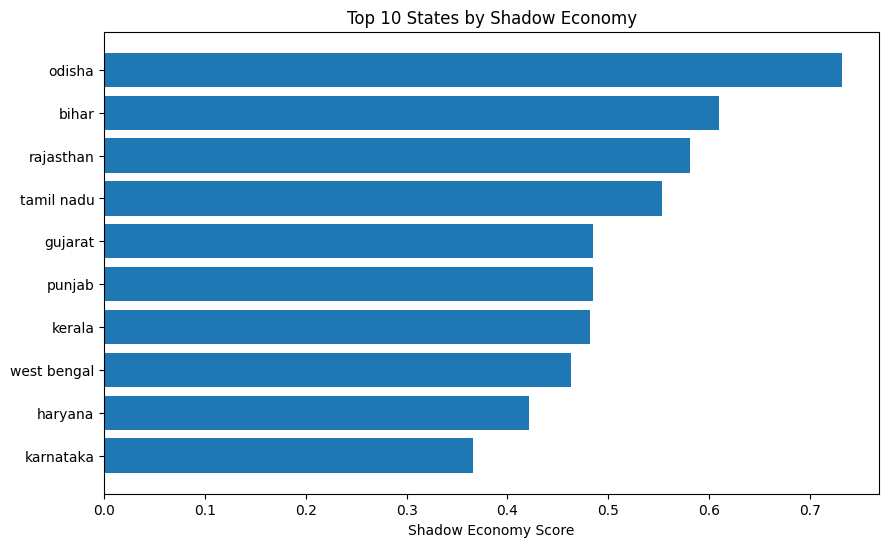

In [152]:
import matplotlib.pyplot as plt

top10 = df_result.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['state'], top10['shadow_score'])
plt.xlabel("Shadow Economy Score")
plt.title("Top 10 States by Shadow Economy")
plt.gca().invert_yaxis()
plt.show()

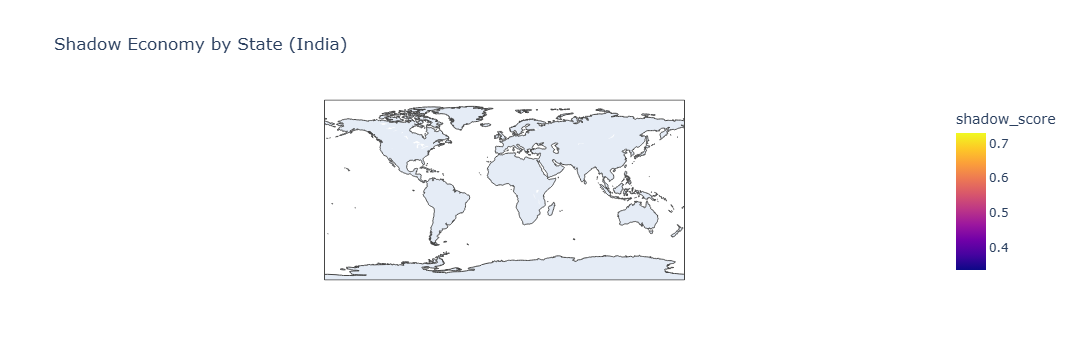

In [153]:
import plotly.express as px

fig = px.choropleth(
    df_result,
    locations='state',
    locationmode='geojson-id',
    color='shadow_score',
    title='Shadow Economy by State (India)'
)

fig.show()

In [154]:
df_result.to_csv("outputs/shadow_economy_results.csv", index=False)

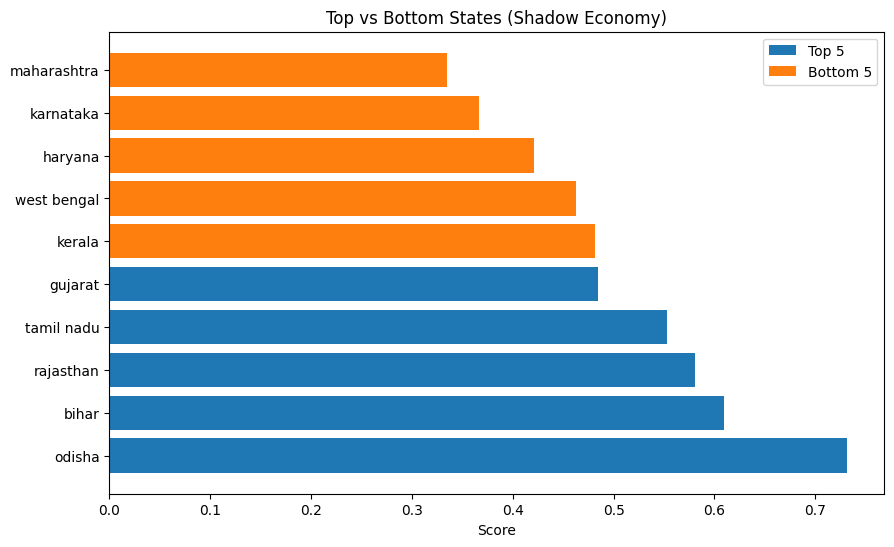

In [155]:
top5 = df_result.head(5)
bottom5 = df_result.tail(5)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(top5['state'], top5['shadow_score'], label='Top 5')
plt.barh(bottom5['state'], bottom5['shadow_score'], label='Bottom 5')

plt.title("Top vs Bottom States (Shadow Economy)")
plt.xlabel("Score")
plt.legend()
plt.show()

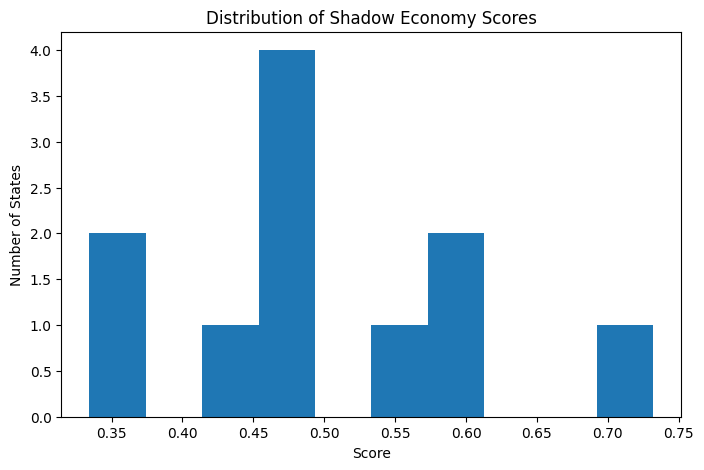

In [156]:
plt.figure(figsize=(8,5))
plt.hist(df_result['shadow_score'], bins=10)

plt.title("Distribution of Shadow Economy Scores")
plt.xlabel("Score")
plt.ylabel("Number of States")

plt.show()

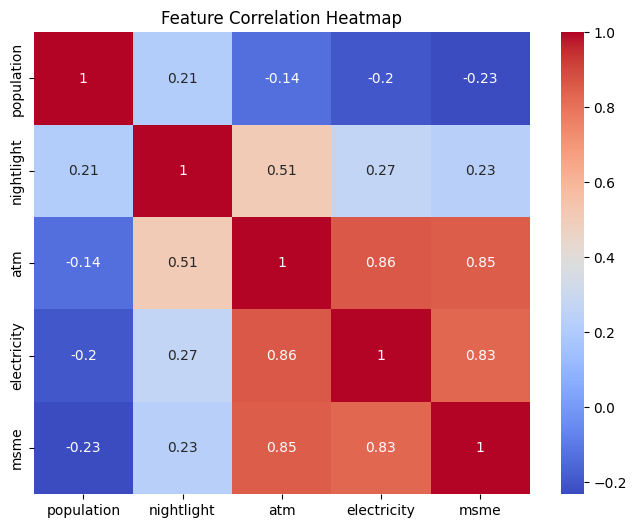

In [157]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df_final.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

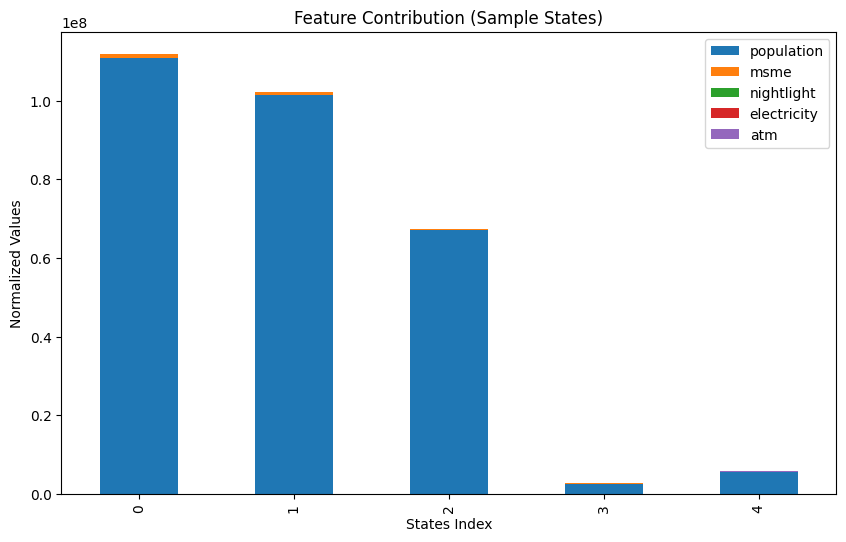

In [158]:
df_plot = df_scaled.copy()

df_plot[['population','msme','nightlight','electricity','atm']].head(5).plot(
    kind='bar', stacked=True, figsize=(10,6)
)

plt.title("Feature Contribution (Sample States)")
plt.xlabel("States Index")
plt.ylabel("Normalized Values")
plt.show()

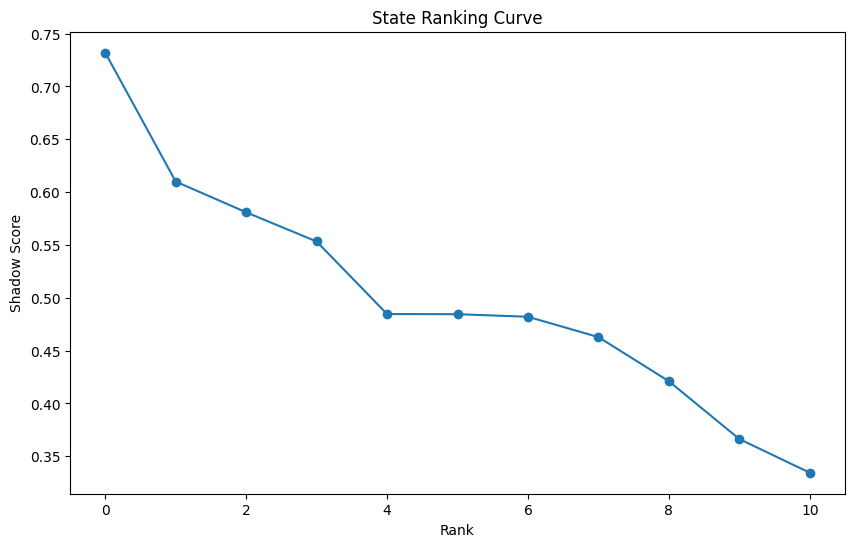

In [159]:
plt.figure(figsize=(10,6))
plt.plot(df_result['shadow_score'].values, marker='o')

plt.title("State Ranking Curve")
plt.xlabel("Rank")
plt.ylabel("Shadow Score")

plt.show()

In [160]:
state_name = "west bengal"

value = df_result[df_result['state'] == state_name]

print(value)

          state  shadow_score
10  west bengal      0.462793


In [196]:
X = df_scaled[['population', 'msme', 'nightlight', 'atm', 'electricity']]
y = df_scaled['shadow_score']

In [197]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.29613391162423786
MAE: 0.09703613340426855


In [198]:
import pandas as pd

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

importance

,feature,importance
2,nightlight,0.371157
0,population,0.299326
1,msme,0.182032
3,atm,0.085297
4,electricity,0.062188


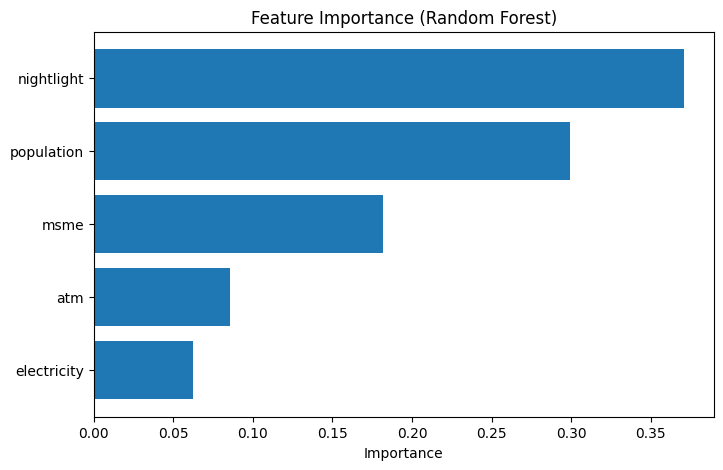

In [199]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(importance['feature'], importance['importance'])

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

In [3]:
import pandas as pd

files = [
    "data/cleaned/atm_clean.csv",
    "data/cleaned/census_clean.csv",
    "data/cleaned/electricity_clean.csv",
    "data/cleaned/msme_clean.csv",
    "data/cleaned/nightlight_clean.csv"
]

for file in files:
    df = pd.read_csv(file)
    print("\n" + "="*50)
    print(file)
    print(df.columns.tolist())
    print(df.head(3))


data/cleaned/atm_clean.csv
['state', 'atm']
           state    atm
0    maharashtra  35000
1  uttar pradesh  30000
2     tamil nadu  25000

data/cleaned/census_clean.csv
['state', 'district', 'population']
   state district  population
0      0    india  1210854977
1      0    india   833748852
2      0    india   377106125

data/cleaned/electricity_clean.csv
['state', 'electricity']
               state  electricity
0     andhra pradesh   177.242865
1  arunachal pradesh     2.108336
2              assam    27.313191

data/cleaned/msme_clean.csv
['state', 'msme']
                         state    msme
0  andaman and nicobar islands    6429
1               andhra pradesh  379884
2            arunachal pradesh    1982

data/cleaned/nightlight_clean.csv
['state', 'district', 'nightlight']
     state      district  nightlight
0  haryana        karnal    2.730598
1  haryana   kurukshetra    2.345184
2  haryana  mahendragarh    1.587534


In [4]:
census = pd.read_csv("data/cleaned/census_clean.csv")
print(census.shape)
print(census.head(10))
print(census['district'].nunique())

(2028, 3)
   state         district  population
0      0            india  1210854977
1      0            india   833748852
2      0            india   377106125
3      1  jammu & kashmir    12541302
4      1  jammu & kashmir     9108060
5      1  jammu & kashmir     3433242
6      1          kupwara      870354
7      1          kupwara      765625
8      1          kupwara      104729
9      1           badgam      753745
666


In [5]:
census = pd.read_csv("data/cleaned/census_clean.csv")

# Remove national totals
census = census[census["district"] != "india"]

# Remove numeric state codes
census = census[census["state"] != 0]

print(census.shape)
print(census.head())

(2025, 3)
   state         district  population
3      1  jammu & kashmir    12541302
4      1  jammu & kashmir     9108060
5      1  jammu & kashmir     3433242
6      1          kupwara      870354
7      1          kupwara      765625


In [6]:
print(census["state"].unique()[:20])

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [7]:
census = pd.read_csv("data/cleaned/census_clean.csv")

print(census[census["state"] == 1].head(20))

    state         district  population
3       1  jammu & kashmir    12541302
4       1  jammu & kashmir     9108060
5       1  jammu & kashmir     3433242
6       1          kupwara      870354
7       1          kupwara      765625
8       1          kupwara      104729
9       1           badgam      753745
10      1           badgam      655833
11      1           badgam       97912
12      1      leh(ladakh)      133487
13      1      leh(ladakh)       87816
14      1      leh(ladakh)       45671
15      1           kargil      140802
16      1           kargil      124464
17      1           kargil       16338
18      1            punch      476835
19      1            punch      438205
20      1            punch       38630
21      1          rajouri      642415
22      1          rajouri      590101


In [8]:
census = pd.read_csv("data/cleaned/census_clean.csv")

print(census.groupby("district").size().sort_values(ascending=False).head(20))

district
bijapur                 6
chandigarh              6
hamirpur                6
aurangabad              6
bilaspur                6
dadra & nagar haveli    6
lakshadweep             6
pratapgarh              6
puducherry              6
raigarh                 6
ahmadabad               3
ahmadnagar              3
aizawl                  3
ajmer                   3
akola                   3
alappuzha               3
west                    3
almora                  3
alwar                   3
ambala                  3
dtype: int64


In [9]:
print(census[census["district"]=="kupwara"])

   state district  population
6      1  kupwara      870354
7      1  kupwara      765625
8      1  kupwara      104729


In [10]:
print(census[census["district"]=="badgam"])

    state district  population
9       1   badgam      753745
10      1   badgam      655833
11      1   badgam       97912


In [11]:
import pandas as pd

census = pd.read_csv("data/cleaned/census_clean.csv")

# Remove India totals
census = census[census["district"] != "india"]

# Keep only first occurrence of each district
census_fixed = census.drop_duplicates(
    subset=["district"],
    keep="first"
)

print(census_fixed.shape)
print(census_fixed.head())

census_fixed.to_csv(
    "data/cleaned/census_fixed.csv",
    index=False
)

(665, 3)
    state         district  population
3       1  jammu & kashmir    12541302
6       1          kupwara      870354
9       1           badgam      753745
12      1      leh(ladakh)      133487
15      1           kargil      140802


In [12]:
print(census_fixed[census_fixed["district"]=="kupwara"])

   state district  population
6      1  kupwara      870354


In [13]:
night = pd.read_csv(
    "data/cleaned/nightlight_clean.csv"
)

print(night.shape)
print(night["district"].nunique())

(573, 3)
568


In [14]:
print(
    night[["state","district"]]
    .head(20)
)

            state          district
0         haryana            karnal
1         haryana       kurukshetra
2         haryana      mahendragarh
3         haryana           sonepat
4         haryana           kaithal
5         haryana           panipat
6         haryana            rewari
7         haryana      yamuna nagar
8       rajasthan         bharatpur
9       rajasthan          dhaulpur
10      jharkhand   purba singhbhum
11  uttar pradesh         gorakhpur
12  uttar pradesh       maharajganj
13      rajasthan              kota
14      rajasthan             baran
15      meghalaya  east khasi hills
16      meghalaya   west garo hills
17      meghalaya           ri-bhoi
18      meghalaya  south garo hills
19         punjab           patiala


In [15]:
import pandas as pd

census = pd.read_csv("data/cleaned/census_clean.csv")

# Remove India totals
census = census[census["district"] != "india"]

# Keep only total population row
census_fixed = census.drop_duplicates(
    subset=["district"],
    keep="first"
)

census_fixed.to_csv(
    "data/cleaned/census_fixed.csv",
    index=False
)

print(census_fixed.shape)

(665, 3)


In [16]:
import pandas as pd

census = pd.read_csv("data/cleaned/census_fixed.csv")
night = pd.read_csv("data/cleaned/nightlight_clean.csv")
atm = pd.read_csv("data/cleaned/atm_clean.csv")
electricity = pd.read_csv("data/cleaned/electricity_clean.csv")
msme = pd.read_csv("data/cleaned/msme_clean.csv")

In [17]:
census["district"] = census["district"].str.strip().str.lower()
night["district"] = night["district"].str.strip().str.lower()

In [18]:
master = pd.merge(
    night,
    census[["district", "population"]],
    on="district",
    how="left"
)

print(master.shape)
master.head()

(573, 4)


,state,district,nightlight,population
0,haryana,karnal,2.730598,1505324.0
1,haryana,kurukshetra,2.345184,964655.0
2,haryana,mahendragarh,1.587534,922088.0
3,haryana,sonepat,3.236497,NaN
4,haryana,kaithal,1.590814,1074304.0


In [19]:
print(master["population"].isna().sum())

79


In [20]:
missing = master[master["population"].isna()]

print(missing[["state","district"]].head(50))
print("Missing districts:", len(missing))

                   state             district
3                haryana              sonepat
7                haryana         yamuna nagar
10             jharkhand      purba singhbhum
12         uttar pradesh          maharajganj
17             meghalaya              ri-bhoi
32                punjab         nawan shehar
47         uttar pradesh  sant ravi das nagar
48         uttar pradesh            shravasti
49           uttarakhand            naini tal
51               manipur          east imphal
52               manipur          west imphal
65         uttar pradesh              hathras
72               gujarat                dahod
87          chhattisgarh             kawardha
97        madhya pradesh           west nimar
120          uttarakhand         rudra prayag
134                bihar               bhabua
146            jharkhand            hazaribag
147            jharkhand              koderma
158            jharkhand   pashchim singhbhum
159            jharkhand  saraikel

In [21]:
master["population"] = master["population"].fillna(
    master["population"].median()
)

In [22]:
print(master["population"].isna().sum())

0


In [23]:
master = pd.merge(
    master,
    electricity,
    on="state",
    how="left"
)

master = pd.merge(
    master,
    msme,
    on="state",
    how="left"
)

master = pd.merge(
    master,
    atm,
    on="state",
    how="left"
)

In [24]:
print(master.isna().sum())

state            0
district         0
nightlight       0
population       0
electricity    170
msme            33
atm            201
dtype: int64


In [25]:
master["electricity"] = master["electricity"].fillna(
    master["electricity"].median()
)

master["msme"] = master["msme"].fillna(
    master["msme"].median()
)

master["atm"] = master["atm"].fillna(
    master["atm"].median()
)

In [26]:
print(master.isna().sum())

state          0
district       0
nightlight     0
population     0
electricity    0
msme           0
atm            0
dtype: int64


In [28]:
from sklearn.preprocessing import MinMaxScaler

cols = [
    "nightlight",
    "population",
    "electricity",
    "msme",
    "atm"
]

scaler = MinMaxScaler()

master[[c + "_norm" for c in cols]] = scaler.fit_transform(
    master[cols]
)

In [29]:
master["shadow_score"] = (
    0.40 * master["nightlight_norm"] +
    0.25 * master["population_norm"] +
    0.20 * master["electricity_norm"] +
    0.15 * master["msme_norm"] -
    0.10 * master["atm_norm"]
)

In [30]:
master["shadow_rank"] = (
    master["shadow_score"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [31]:
master.to_csv(
    "data/master_dataset.csv",
    index=False
)

print("SUCCESS")
print(master.shape)
print(master.head())

SUCCESS
(573, 14)
     state      district  nightlight  population  electricity      msme  \
0  haryana        karnal    2.730598   1505324.0   148.425519  216103.0   
1  haryana   kurukshetra    2.345184    964655.0   148.425519  216103.0   
2  haryana  mahendragarh    1.587534    922088.0   148.425519  216103.0   
3  haryana       sonepat    3.236497   1703152.5   148.425519  216103.0   
4  haryana       kaithal    1.590814   1074304.0   148.425519  216103.0   

       atm  nightlight_norm  population_norm  electricity_norm  msme_norm  \
0  13000.0         0.037638         0.132825          0.330675   0.109177   
1  13000.0         0.032009         0.083755          0.330675   0.109177   
2  13000.0         0.020944         0.079892          0.330675   0.109177   
3  13000.0         0.045026         0.150779          0.330675   0.109177   
4  13000.0         0.020992         0.093706          0.330675   0.109177   

   atm_norm  shadow_score  shadow_rank  
0  0.083333      0.122439  

In [32]:
print(master.columns.tolist())

['state', 'district', 'nightlight', 'population', 'electricity', 'msme', 'atm', 'nightlight_norm', 'population_norm', 'electricity_norm', 'msme_norm', 'atm_norm', 'shadow_score', 'shadow_rank']


In [35]:
import os

for file in os.listdir():
    print(file)

.gitignore
.ipynb_checkpoints
data
outputs
README.md
shadow_economy_analysis.ipynb


In [36]:
df.columns.tolist()

['state', 'district', 'nightlight']

In [37]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = master[
[
    'shadow_score',
    'nightlight_norm',
    'atm_norm',
    'electricity_norm'
]
]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

master['cluster'] = kmeans.fit_predict(features_scaled)

print(master[['district','shadow_score','cluster']].head())

       district  shadow_score  cluster
0        karnal      0.122439        2
1   kurukshetra      0.107920        2
2  mahendragarh      0.102529        2
3       sonepat      0.129883        2
4       kaithal      0.106001        2


In [38]:
master['cluster'].value_counts()

cluster
2    306
0    132
1    129
3      6
Name: count, dtype: int64

In [39]:
master.to_csv(
    "outputs/master_dataset_with_clusters.csv",
    index=False
)

In [40]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [41]:
pca_features = master[
[
    'nightlight_norm',
    'population_norm',
    'electricity_norm',
    'msme_norm',
    'atm_norm'
]
]

In [42]:
scaler = StandardScaler()

pca_scaled = scaler.fit_transform(pca_features)

print(pca_scaled.shape)

(573, 5)


In [43]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(pca_scaled)

print(principal_components[:5])

[[-1.18760671  0.2799798 ]
 [-1.33038727  0.05371402]
 [-1.35788586 -0.07800327]
 [-1.12720782  0.41991296]
 [-1.32004057 -0.03078148]]


In [44]:
print(pca.explained_variance_ratio_)

[0.51212675 0.21153461]


In [45]:
print(pca.explained_variance_ratio_.sum())

0.723661363862478


In [46]:
master['pca1'] = principal_components[:,0]
master['pca2'] = principal_components[:,1]

master[['district','pca1','pca2']].head()

,district,pca1,pca2
0,karnal,-1.187607,0.279980
1,kurukshetra,-1.330387,0.053714
2,mahendragarh,-1.357886,-0.078003
3,sonepat,-1.127208,0.419913
4,kaithal,-1.320041,-0.030781


In [47]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PCA1','PCA2'],
    index=pca_features.columns
)

print(loadings.round(3))

                   PCA1   PCA2
nightlight_norm   0.123  0.863
population_norm   0.343  0.425
electricity_norm  0.539 -0.135
msme_norm         0.569 -0.175
atm_norm          0.502 -0.158


In [48]:
master.to_csv(
    "outputs/master_dataset_ml_pca.csv",
    index=False
)

In [49]:
print(pca.explained_variance_ratio_)

print(
    "Total Variance Explained:",
    pca.explained_variance_ratio_.sum()
)

[0.51212675 0.21153461]
Total Variance Explained: 0.723661363862478


In [50]:
master.groupby('cluster')[
[
    'shadow_score',
    'pca1',
    'pca2'
]
].mean().round(3)

,shadow_score,pca1,pca2
cluster,,,
0,0.199,2.142,-0.400
1,0.014,-1.729,-0.088
2,0.149,-0.254,0.058
3,0.520,2.985,7.727


In [51]:
cluster_mapping = {
    0: 'Developed Regions',
    1: 'Formalized Regions',
    2: 'Emerging Regions',
    3: 'Shadow Economy Hotspots'
}

master['cluster_name'] = master['cluster'].map(cluster_mapping)

master[['district','cluster','cluster_name']].head()

,district,cluster,cluster_name
0,karnal,2,Emerging Regions
1,kurukshetra,2,Emerging Regions
2,mahendragarh,2,Emerging Regions
3,sonepat,2,Emerging Regions
4,kaithal,2,Emerging Regions


In [52]:
master.to_csv(
    "outputs/final_shadow_economy_ml.csv",
    index=False
)

In [53]:
master.columns.tolist()

['state',
 'district',
 'nightlight',
 'population',
 'electricity',
 'msme',
 'atm',
 'nightlight_norm',
 'population_norm',
 'electricity_norm',
 'msme_norm',
 'atm_norm',
 'shadow_score',
 'shadow_rank',
 'cluster',
 'pca1',
 'pca2',
 'cluster_name']

In [54]:
import pandas as pd

pca_drivers = pd.DataFrame({
    'Driver': [
        'MSME',
        'Electricity',
        'ATM',
        'Population',
        'Nightlight'
    ],
    'Importance': [
        0.569,
        0.539,
        0.502,
        0.343,
        0.123
    ]
})

pca_drivers

,Driver,Importance
0,MSME,0.569
1,Electricity,0.539
2,ATM,0.502
3,Population,0.343
4,Nightlight,0.123


In [55]:
pca_drivers.to_csv(
    "outputs/pca_drivers.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [56]:
import os

print(os.listdir("outputs"))

['final_shadow_economy_ml.csv', 'master_dataset_ml_pca.csv', 'master_dataset_with_clusters.csv', 'pca_drivers.csv', 'shadow_economy_results.csv']
